## Assignment 3: Comparison of ensemble approaches on gene expression data

In [345]:
import pandas as pd
import polars as pl
import numpy as np
from tqdm import tqdm
from sklearn import cluster
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import os
from statsmodels.formula.api import ols, logit
import seaborn as sns
from sklearn.decomposition import PCA
import umap
import warnings

from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

In [346]:
# functions for the assignments
def genes_variance(sample_data):
    genes_vars = {}
    for row_idx in tqdm(range(sample_data.shape[0])):
        row = sample_data.row(row_idx)
        gene_ensembl_id = row[0]
        # min max of the rows
        gene_exp = row[2:]
        normalized_gene_exp = (gene_exp - np.min(gene_exp)) / (np.max(gene_exp) - np.min(gene_exp))
        genes_vars[gene_ensembl_id] = np.var(row[2:])
    return genes_vars

In [347]:
# constants
plt.rcParams["figure.figsize"] = (12,8)

## 0. Data Download and Preprocessing

In [348]:
# download the data

# tpm data
tpm_url = "https://storage.googleapis.com/adult-gtex/bulk-gex/v8/rna-seq/GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_tpm.gct.gz"
tpm_file_path = "../data/GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_tpm.gct.gz"
if not os.path.exists(tpm_file_path):
    tpm_cmd = f"curl --output {tpm_file_path} {tpm_url}"
    os.system(tpm_cmd)


# phenotypes
phenotype_url = "https://storage.googleapis.com/adult-gtex/annotations/v8/metadata-files/GTEx_Analysis_v8_Annotations_SubjectPhenotypesDS.txt"
phenotype_file_path = "../data/GTEx_Analysis_v8_Annotations_SubjectPhenotypesDS.txt"
if not os.path.exists(phenotype_file_path):
    phenotype_cmd = f"curl --output {phenotype_file_path} {phenotype_url}"
    os.system(phenotype_cmd)

# metadata
meta_url = "https://storage.googleapis.com/adult-gtex/annotations/v8/metadata-files/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt"
meta_file_path = "../data/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt"
if not os.path.exists(meta_file_path):
    meta_cmd = f"curl --output {meta_file_path} {meta_url}"
    os.system(meta_cmd)

In [349]:
# load metadata files
metadata_df = pd.read_csv(
    meta_file_path, 
    sep='\t'
)
print(metadata_df[metadata_df.SAMPID == "GTEX-1117F-0003-SM-58Q7G"]['SMTS'])

0    Blood
Name: SMTS, dtype: object


In [350]:
# Load TPM data
tpm_lazy_df = pl.read_csv(
    source = tpm_file_path, 
    separator = "\t", 
    skip_rows = 2
) 

In [351]:
# phenotypes data
phenotype_df = pd.read_csv(
    phenotype_file_path, 
    sep='\t'
)
phenotype_df.head()

,SUBJID,SEX,AGE,DTHHRDY
0,GTEX-1117F,2,60-69,4.0
1,GTEX-111CU,1,50-59,0.0
2,GTEX-111FC,1,60-69,1.0
3,GTEX-111VG,1,60-69,3.0
4,GTEX-111YS,1,60-69,0.0


In [364]:
# merge metadata df + phenotypes data
metadata_df['SUBJID'] = ""
metadata_df['SUBJID'] = metadata_df['SAMPID'].apply(
    lambda x: "-".join(x.split("-")[:2])
)

metadata_df = metadata_df.merge(
    phenotype_df, 
    on = "SUBJID"
)

In [354]:
# subset the data
# - Use the metadata file to select the top 10 tissues with the largest sample size.
top_10_tissues = metadata_df.SMTS.value_counts().nlargest(10).reset_index()[['SMTS']].values.flatten()
print(f'Top ten tissues by sample size: \n  {top_10_tissues}')

# - only keep the columns for top 10 tissues
top_10_tissues_ids = np.unique(metadata_df[metadata_df.SMTS.isin(top_10_tissues)].SAMPID.values)
print(f"The ids for top 10 tissues are: {len(top_10_tissues_ids)}")
# - only get those IDs present in tpm count data
tpm_df_colums = np.array(tpm_lazy_df.columns)
top_10_tissues_ids = [ tissue_id for tissue_id in top_10_tissues_ids if tissue_id in tpm_df_colums]

print(f"The ids for top 10 tissues are and in tpm data: {len(top_10_tissues_ids)}")
top_10_tissues_ids.insert(0, "Name")
# only subset the data from top 10 tissues
top_10_tissues_subset = tpm_lazy_df.select(top_10_tissues_ids)
print(top_10_tissues_subset.shape)

Top ten tissues by sample size: 
  ['Blood' 'Brain' 'Skin' 'Esophagus' 'Blood Vessel' 'Adipose Tissue'
 'Heart' 'Muscle' 'Lung' 'Colon']
The ids for top 10 tissues are: 17163
The ids for top 10 tissues are and in tpm data: 12385
(56200, 12386)


In [355]:
# get top k variable genes
topk = 5000
gene_variances = genes_variance(top_10_tissues_subset)
top_var_genes = sorted(gene_variances.items(), key=lambda item: item[1], reverse=True)[:topk]
most_variables_genes = [k[0] for k in top_var_genes]

  0%|                                                                                                                                                                                                          | 25/56200 [00:01<49:33, 18.89it/s]/var/folders/rd/c2tlh0qn3y7fvt1bwwd_d2x80000gn/T/ipykernel_66200/13535060.py:9: RuntimeWarning: invalid value encountered in divide
  normalized_gene_exp = (gene_exp - np.min(gene_exp)) / (np.max(gene_exp) - np.min(gene_exp))
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 56200/56200 [04:38<00:00, 201.87it/s]


In [365]:
# subset the data by most variables genes
prepped_data = top_10_tissues_subset.filter(
    pl.col('Name').is_in(most_variables_genes)
).to_pandas()
prepped_data = prepped_data.reset_index(drop=True).set_index("Name").T

prepped_data = prepped_data.reset_index().merge(
    metadata_df[['SAMPID', 'SMTS', 'SEX', 'AGE']], 
    left_on = "index", 
    right_on = "SAMPID"
).drop(['index', 'SAMPID'], axis = 1)
prepped_data['tissue'] = prepped_data.SMTS
prepped_data.drop(columns = ['SMTS'], axis = 1, inplace = True)
prepped_data.head()

,ENSG00000268903.1,ENSG00000269981.1,ENSG00000225972.1,ENSG00000225630.1,ENSG00000237973.1,ENSG00000229344.1,ENSG00000240409.1,ENSG00000248527.1,ENSG00000198744.5,ENSG00000188976.10,...,ENSG00000210191.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2,ENSG00000210195.2,ENSG00000210196.2,SEX,AGE,tissue
0,3.2150,7.0120,8.532,359.0,27.950,11.680,22.81,1433.0,23.140,90.74,...,0.0000,2928.0,3799.0,16.240,6938.0,0.943,0.000,2,60-69,Adipose Tissue
1,0.2492,0.4969,31.870,650.7,68.360,30.210,74.21,5677.0,246.200,93.56,...,0.0000,10400.0,14750.0,44.310,26310.0,6.414,6.226,2,60-69,Muscle
2,1.3560,0.4806,13.210,281.0,24.550,11.210,21.62,1537.0,22.870,94.87,...,0.0000,4471.0,6728.0,23.740,8455.0,1.034,1.004,2,60-69,Blood Vessel
3,1.8610,1.8550,3.935,424.2,8.134,4.292,10.91,1846.0,8.578,67.60,...,0.0000,1237.0,817.3,0.000,8799.0,0.000,0.000,2,60-69,Blood Vessel
4,0.9263,1.7790,8.565,638.5,101.800,16.810,23.41,10320.0,32.520,26.52,...,0.5473,7780.0,7051.0,2.252,29170.0,0.000,2.857,2,60-69,Heart


## 1. Dimensionality reduction

In [366]:
X, y = prepped_data.drop(columns = ['tissue', 'SEX', 'AGE']).to_numpy(), prepped_data['tissue'].to_numpy()

# scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

1. Apply PCA and (if your computer's resources allow) another dimensionality reduction technique to visualize the data.

[Text(0.5, 0, 'PC1'), Text(0, 0.5, 'PC2')]

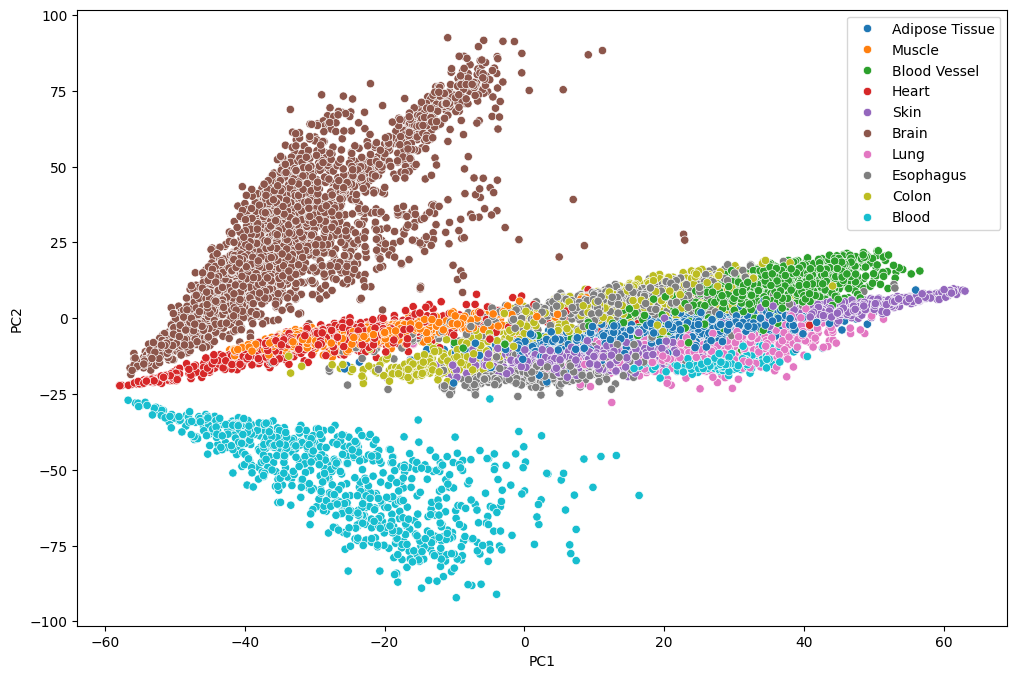

In [367]:
# PCA 
np.random.seed(0)
n_components = 2
pca_X = PCA(n_components = n_components).fit_transform(X_scaled)
plot = sns.scatterplot(
    x = pca_X[:, 0], 
    y = pca_X[:, 1], 
    hue = y
)
plot.set(xlabel="PC1", ylabel="PC2")

[Text(0.5, 0, 'UMAP 1'), Text(0, 0.5, 'UMAP 2')]

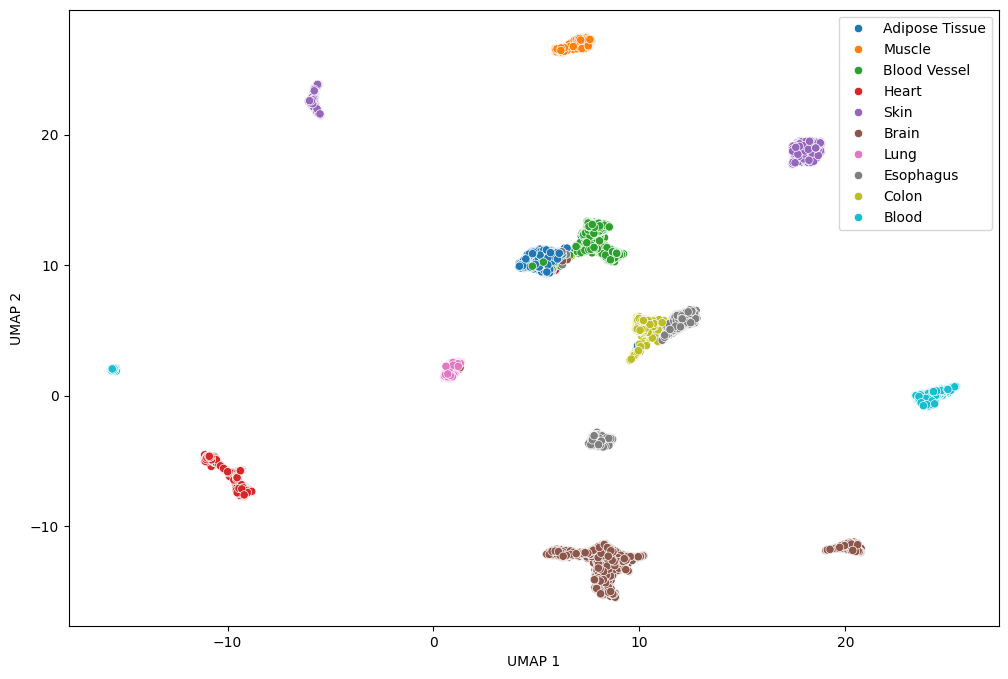

In [368]:
# UMAP clustering
np.random.seed(0)
umap_X = umap.UMAP(n_neighbors=30).fit_transform(X_scaled)

n_components = 2
plot = sns.scatterplot(
    x = umap_X[:, 0], 
    y = umap_X[:, 1], 
    hue = y
)
plot.set(xlabel="UMAP 1", ylabel="UMAP 2")

__Visualize Lower dimensional data__

    The PCA has more elongated clusters, whereas UMAP clusters are more compact and group more tightly. 

2. Change the parameters of the dimensionality reduction techniques (in particular, the number of components) to generate different latent spaces and assess how they impact cluster analysis. For this, select the best clustering algorithm that you identified in Assignment 1, and group samples together using the different latent spaces.

In [91]:
np.random.seed(0)
KS = range(2, 20)

# internal metrics
spec_perf_d = {}

for k in tqdm(KS):
    
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="Graph is not fully connected, spectral embedding"
            + " may not work as expected.",
            category=UserWarning,
        )
        model = cluster.SpectralClustering(
            n_clusters=k, 
            affinity="nearest_neighbors", 
            n_init=1
        )
        predicted_labels = model.fit_predict(X_scaled)
        
        # external metrics
        spec_perf_c[k] = calinski_harabasz_score(X_scaled, predicted_labels)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [15:03<00:00, 50.17s/it]


<Axes: >

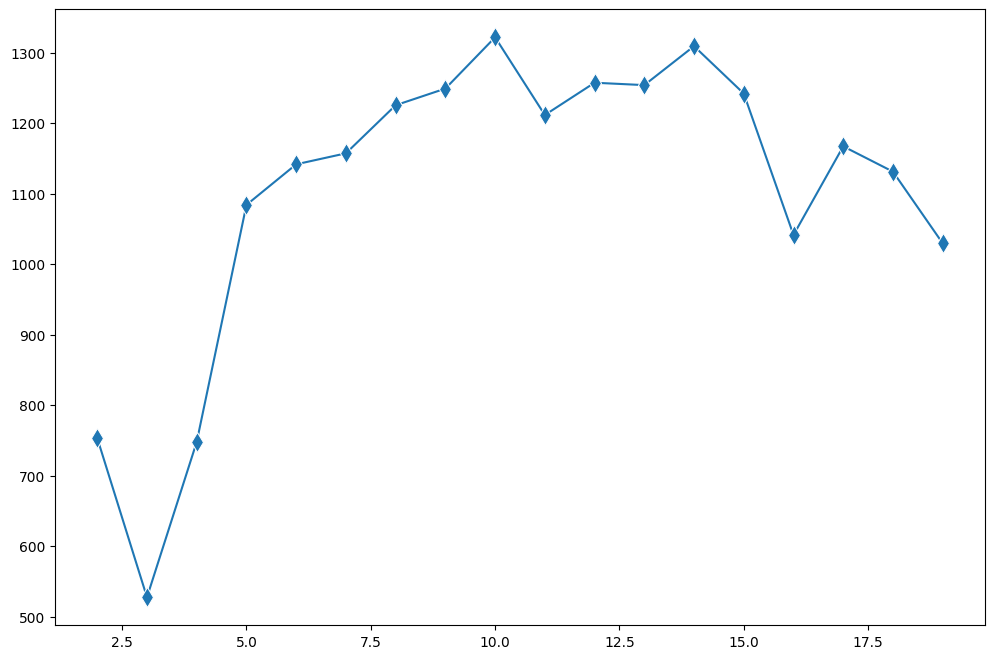

In [211]:
spec_perf_c.keys()
sns.lineplot(
    x = spec_perf_c.keys(), 
    y = spec_perf_c.values(), 
    marker = "d",
    markersize = 10
)

In [308]:
k = 10
model = cluster.SpectralClustering(
    n_clusters=k, 
    affinity="nearest_neighbors", 
    n_init=1
)

3. Compare each latent space in terms of its ability to group samples according to their tissue of origin.

## 2. Ensemble-based models to predict tissue

1. Using samples projected into the different latent spaces, use at least two ensemble approaches to predict their tissue of origin:

    a. One approach must use a learner/estimator that tends to overfit data.
   
    b. Another approach must use a weak learner that slightly outperforms a random estimator.

In [369]:
tissue_maps = {}
for idx, tissue in enumerate(np.unique(y)):
    tissue_maps[tissue] = idx

ylabel = np.array([tissue_maps.get(label) for label in y])

# X train split; 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,  ylabel, 
    stratify = ylabel
)

# Use PC 5 for classification
n_components = 10
pca = PCA(n_components = n_components).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [372]:
# a. approach with learner that overfit; use bagging with decision tree classifier
bagging_ensembler = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100, 
        random_state=0
)
bagging_ensembler.fit(X_train_pca, y_train)
y_pred = bagging_ensembler.predict(X_test_pca)
print(classification_report(y_test, y_pred, target_names=np.unique(y)))

                precision    recall  f1-score   support

Adipose Tissue       0.95      0.98      0.97       301
         Blood       1.00      1.00      1.00       232
  Blood Vessel       0.98      0.97      0.98       334
         Brain       1.00      1.00      1.00       661
         Colon       0.90      0.81      0.85       195
     Esophagus       0.90      0.94      0.92       361
         Heart       0.98      1.00      0.99       215
          Lung       0.99      0.98      0.98       145
        Muscle       1.00      1.00      1.00       201
          Skin       1.00      1.00      1.00       452

      accuracy                           0.97      3097
     macro avg       0.97      0.97      0.97      3097
  weighted avg       0.97      0.97      0.97      3097



In [376]:
# b. Another approach must use a weak learner that slightly outperforms a random estimator.
gradient_boost = GradientBoostingClassifier(
    n_estimators=100, 
    max_depth=1, 
    random_state=0
).fit(X_train_pca, y_train)
gradient_boost.fit(X_train_pca, y_train)
y_pred = gradient_boost.predict(X_test_pca)
print(classification_report(y_test, y_pred, target_names=np.unique(y)))

                precision    recall  f1-score   support

Adipose Tissue       0.96      0.99      0.97       301
         Blood       1.00      1.00      1.00       232
  Blood Vessel       0.98      0.96      0.97       334
         Brain       1.00      1.00      1.00       661
         Colon       0.90      0.74      0.81       195
     Esophagus       0.86      0.94      0.90       361
         Heart       0.99      0.98      0.98       215
          Lung       0.98      0.99      0.98       145
        Muscle       0.99      0.99      0.99       201
          Skin       1.00      1.00      1.00       452

      accuracy                           0.97      3097
     macro avg       0.97      0.96      0.96      3097
  weighted avg       0.97      0.97      0.97      3097



2. Use a model evaluation strategy that allows you to play with different hyperparameters to select the best model, assess whether the models are good predictors across all tissues (take a look at the classification_reportLinks to an external site. function in sklearn) and whether they generalize well on unseen data.

In [378]:
# bagging best parameters search 
bagging_ensembler = BaggingClassifier(estimator=DecisionTreeClassifier(),random_state=0)
parameters = {
    "n_estimators" : list(range(10, 120, 30))
}
grid = GridSearchCV(bagging_ensembler, parameters, cv = 2, scoring = "accuracy", verbose = 2)
grid.fit(X_train_pca, y_train)

best_params = grid.cv_results_['params'][grid.best_index_]
print(best_params)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV] END ....................................n_estimators=10; total time=   0.3s
[CV] END ....................................n_estimators=10; total time=   0.3s
[CV] END ....................................n_estimators=40; total time=   1.1s
[CV] END ....................................n_estimators=40; total time=   1.0s
[CV] END ....................................n_estimators=70; total time=   1.9s
[CV] END ....................................n_estimators=70; total time=   2.1s
[CV] END ...................................n_estimators=100; total time=   2.8s
[CV] END ...................................n_estimators=100; total time=   2.6s
{'n_estimators': 40}


In [380]:
best_model = BaggingClassifier(
    **best_params, 
    random_state=0
).fit(X_train_pca, y_train)

# classification report on train
print("Training Accuracy")
y_pred = best_model.predict(X_train_pca)
print(classification_report(y_train, y_pred, target_names=np.unique(y)))

# classification report on test
print("Testing Accuracy")
y_pred = best_model.predict(X_test_pca)
print(classification_report(y_test, y_pred, target_names=np.unique(y)))

Training Accuracy
                precision    recall  f1-score   support

Adipose Tissue       1.00      1.00      1.00       903
         Blood       1.00      1.00      1.00       697
  Blood Vessel       1.00      1.00      1.00      1001
         Brain       1.00      1.00      1.00      1981
         Colon       1.00      1.00      1.00       584
     Esophagus       1.00      1.00      1.00      1084
         Heart       1.00      1.00      1.00       646
          Lung       1.00      1.00      1.00       433
        Muscle       1.00      1.00      1.00       602
          Skin       1.00      1.00      1.00      1357

      accuracy                           1.00      9288
     macro avg       1.00      1.00      1.00      9288
  weighted avg       1.00      1.00      1.00      9288

Testing Accuracy
                precision    recall  f1-score   support

Adipose Tissue       0.95      0.98      0.97       301
         Blood       1.00      1.00      1.00       232
  Blood V

__Bagging Parameters__

    The best parameter for the bagging is n_estimator = 40, with train accuracy of 100% and test accuracy at 97%. Generally, the performance across the tissues remained high in test data. 

In [381]:
# boosting best parameters.
gradient_boost_clf = GradientBoostingClassifier(random_state=0)
parameters = {
    "n_estimators" : list(range(10, 120, 30)), 
    "learning_rate" : [ 0.01, 0.1, 1], 
    "criterion" : ['squared_error', 'friedman_mse']
}
grid = GridSearchCV(gradient_boost_clf, parameters, cv = 2, scoring = "accuracy", verbose = 2)
grid.fit(X_train_pca, y_train)

Fitting 2 folds for each of 24 candidates, totalling 48 fits
[CV] END criterion=squared_error, learning_rate=0.01, n_estimators=10; total time=   1.9s
[CV] END criterion=squared_error, learning_rate=0.01, n_estimators=10; total time=   1.9s
[CV] END criterion=squared_error, learning_rate=0.01, n_estimators=40; total time=   7.6s
[CV] END criterion=squared_error, learning_rate=0.01, n_estimators=40; total time=   7.6s
[CV] END criterion=squared_error, learning_rate=0.01, n_estimators=70; total time=  13.4s
[CV] END criterion=squared_error, learning_rate=0.01, n_estimators=70; total time=  13.8s
[CV] END criterion=squared_error, learning_rate=0.01, n_estimators=100; total time=  19.2s
[CV] END criterion=squared_error, learning_rate=0.01, n_estimators=100; total time=  19.4s
[CV] END criterion=squared_error, learning_rate=0.1, n_estimators=10; total time=   2.0s
[CV] END criterion=squared_error, learning_rate=0.1, n_estimators=10; total time=   1.9s
[CV] END criterion=squared_error, learn

GridSearchCV(cv=2, estimator=GradientBoostingClassifier(random_state=0),
             param_grid={'criterion': ['squared_error', 'friedman_mse'],
                         'learning_rate': [0.01, 0.1, 1],
                         'n_estimators': [10, 40, 70, 100]},
             scoring='accuracy', verbose=2)

In [382]:
best_params = grid.cv_results_['params'][grid.best_index_]
print(best_params)

{'criterion': 'friedman_mse', 'learning_rate': 0.1, 'n_estimators': 100}


In [383]:
best_model = GradientBoostingClassifier(
    **best_params, 
    random_state=0
).fit(X_train_pca, y_train)

In [384]:
# classification report on train
print("Training Performance")
y_pred = best_model.predict(X_train_pca)
print(classification_report(y_train, y_pred, target_names=np.unique(y)))

# classification report on test
print("Testing performance")
y_pred = best_model.predict(X_test_pca)
print(classification_report(y_test, y_pred, target_names=np.unique(y)))

Training Performance
                precision    recall  f1-score   support

Adipose Tissue       0.99      1.00      1.00       903
         Blood       1.00      1.00      1.00       697
  Blood Vessel       1.00      1.00      1.00      1001
         Brain       1.00      1.00      1.00      1981
         Colon       0.99      0.96      0.97       584
     Esophagus       0.98      0.99      0.99      1084
         Heart       1.00      1.00      1.00       646
          Lung       1.00      1.00      1.00       433
        Muscle       1.00      1.00      1.00       602
          Skin       1.00      1.00      1.00      1357

      accuracy                           1.00      9288
     macro avg       1.00      0.99      1.00      9288
  weighted avg       1.00      1.00      1.00      9288

Testing performance
                precision    recall  f1-score   support

Adipose Tissue       0.96      0.98      0.97       301
         Blood       1.00      1.00      1.00       232
  B

__Gradient Boosting Parameters__

    The best parameters for the models are as follows criterion --> friedman_mse, learning_rate --> 0.1 and n_estimators --> 100. The performance remained the same in both train, and test data. 

## 3. Ensemble-based models to predict age

1. Use at least two ensemble approaches to predict age, ensuring that you are predicting a continuous variable (not a categorical one).

In [385]:
blood_df = prepped_data[prepped_data['tissue'] == "Blood"]
X, y = blood_df.drop(columns = ['SEX', 'AGE', 'tissue']).to_numpy(), blood_df['AGE'].to_numpy()
y_age = np.array([ np.array(age.split("-")).astype(int).mean() for age in y])

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scaler = MinMaxScaler(feature_range=(0, 1))
y_std_age = (y_age - y_age.min()) / (y_age.max() - y_age.min())

# X train split; 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,  
    y_std_age
)

# Use PC 5 for classification
n_components = 5
pca = PCA(n_components = n_components).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [386]:
# bagging
regr = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=10, 
    random_state=0
)
regr.fit(X_train_pca, y_train)
print(f"R2 score train: {r2_score(y_train, regr.predict(X_train_pca)):.4f}")
print(f"R2 score test: {r2_score(y_test, regr.predict(X_test_pca)):.4f}")

R2 score train: 0.8234
R2 score test: -0.1228


In [387]:
# boosting
gradient_regr = GradientBoostingRegressor(n_estimators = 10, random_state=0)
gradient_regr.fit(X_train_pca, y_train)
print(f"R2 score train: {r2_score(y_train, gradient_regr.predict(X_train_pca)):.4f}")
print(f"R2 score test: {r2_score(y_test, gradient_regr.predict(X_test_pca)):.4f}")

R2 score train: 0.1721
R2 score test: 0.0498


__Regression Results__

    For regression, I used BaggingRegressor and GradientBoostingRegressor, which account for overfitting and underfitting, respectively. In the bagging regression, the training R2 was high, but dropped significantly in the test data. The same applied for the GradientBoostingRegressor. So for, this I can say that the regression were not able to generalize to unseen test data.

2. Use a model evaluation strategy that allows you to play with different hyperparameters to select the best model, assess whether the models are good predictors and whether they generalize well on unseen data.

In [392]:
# bagging
bagging_regr = BaggingRegressor(random_state=0)
parameters = {
    "n_estimators" : list(range(10, 200, 30))
}
grid = GridSearchCV(bagging_regr, parameters, cv = 2, scoring = "r2", verbose = 2)
grid.fit(X_train_pca, y_train)

Fitting 2 folds for each of 7 candidates, totalling 14 fits
[CV] END ....................................n_estimators=10; total time=   0.0s
[CV] END ....................................n_estimators=10; total time=   0.0s
[CV] END ....................................n_estimators=40; total time=   0.1s
[CV] END ....................................n_estimators=40; total time=   0.1s
[CV] END ....................................n_estimators=70; total time=   0.1s
[CV] END ....................................n_estimators=70; total time=   0.1s
[CV] END ...................................n_estimators=100; total time=   0.2s
[CV] END ...................................n_estimators=100; total time=   0.2s
[CV] END ...................................n_estimators=130; total time=   0.2s
[CV] END ...................................n_estimators=130; total time=   0.3s
[CV] END ...................................n_estimators=160; total time=   0.3s
[CV] END ...................................n_est

GridSearchCV(cv=2, estimator=BaggingRegressor(random_state=0),
             param_grid={'n_estimators': [10, 40, 70, 100, 130, 160, 190]},
             scoring='r2', verbose=2)

In [394]:
best_params = grid.cv_results_['params'][grid.best_index_]
print(best_params)
best_model = BaggingRegressor(
    **best_params, 
    random_state=0
).fit(X_train_pca, y_train)
print(f"R2 score train: {r2_score(y_train, best_model.predict(X_train_pca)):.4f}")
print(f"R2 score test: {r2_score(y_test, best_model.predict(X_test_pca)):.4f}")

{'n_estimators': 130}
R2 score train: 0.8648
R2 score test: -0.0832


In [388]:
# boosting
parameters = {
    "n_estimators" : list(range(10, 200, 30)), 
    "learning_rate" : [ 0.01, 0.1, 1], 
    "loss" : ['squared_error', 'absolute_error', 'huber', 'quantile'], 
     "criterion" : ['friedman_mse', 'squared_error']
}
gradient_boost_reg = GradientBoostingRegressor(random_state=0)
grid = GridSearchCV(gradient_boost_reg, parameters, cv = 2, scoring = "r2", verbose = 2)
grid.fit(X_train_pca, y_train)

Fitting 2 folds for each of 168 candidates, totalling 336 fits
[CV] END criterion=friedman_mse, learning_rate=0.01, loss=squared_error, n_estimators=10; total time=   0.0s
[CV] END criterion=friedman_mse, learning_rate=0.01, loss=squared_error, n_estimators=10; total time=   0.0s
[CV] END criterion=friedman_mse, learning_rate=0.01, loss=squared_error, n_estimators=40; total time=   0.0s
[CV] END criterion=friedman_mse, learning_rate=0.01, loss=squared_error, n_estimators=40; total time=   0.0s
[CV] END criterion=friedman_mse, learning_rate=0.01, loss=squared_error, n_estimators=70; total time=   0.1s
[CV] END criterion=friedman_mse, learning_rate=0.01, loss=squared_error, n_estimators=70; total time=   0.1s
[CV] END criterion=friedman_mse, learning_rate=0.01, loss=squared_error, n_estimators=100; total time=   0.1s
[CV] END criterion=friedman_mse, learning_rate=0.01, loss=squared_error, n_estimators=100; total time=   0.1s
[CV] END criterion=friedman_mse, learning_rate=0.01, loss=squar

GridSearchCV(cv=2, estimator=GradientBoostingRegressor(random_state=0),
             param_grid={'criterion': ['friedman_mse', 'squared_error'],
                         'learning_rate': [0.01, 0.1, 1],
                         'loss': ['squared_error', 'absolute_error', 'huber',
                                  'quantile'],
                         'n_estimators': [10, 40, 70, 100, 130, 160, 190]},
             scoring='r2', verbose=2)

In [389]:
best_params = grid.cv_results_['params'][grid.best_index_]
print(best_params)

{'criterion': 'friedman_mse', 'learning_rate': 0.01, 'loss': 'squared_error', 'n_estimators': 130}


In [391]:
best_model = GradientBoostingRegressor(
    **best_params, 
    random_state=0
).fit(X_train_pca, y_train)
print(f"R2 score train: {r2_score(y_train, best_model.predict(X_train_pca)):.4f}")
print(f"R2 score test: {r2_score(y_test, best_model.predict(X_test_pca)):.4f}")

R2 score train: 0.1933
R2 score test: 0.0502


__Best Regression Parameters__

For bagging, the best parameters are n_estimators = 130. For the gradient-boosting regressor, the best parameters are criterion: friedman_mse, learning_rate = 0.01, loss: squared_error, and n_estimators = 130.

In both regression models improved in both train and test data, but the R2 for the test data remained low.